In [135]:
from adjustText import adjust_text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')


# DEG

## Data import DEG celltype

In [4]:
# dir_notebook = 'D:/Jupyter_notebook/Xenium_jupyter_notebook'
dir_notebook = '../notebook'

name_dir = 'circa-SD'
control = "circa4"
test = "SD1"


# name_dir = "all-samples-C123"
# control = "WT"
# test = "APP"

df_all = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if control in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test]
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.1) &
          (df_all[key]['mean_count']>= 0.2)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
# df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

# for key in df_filter.keys():
#     df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
#     df_filter[key].index = df_filter[key]['names']

In [5]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] >= 0.1)
                                 & (df_all[key]['pct_nz_reference'] >= 0.1)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >=0.2)
                                 ]
df_filter['SCH_Gaba'].sort_values(by='logfoldchanges',ascending=False)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,mean_count
names,,,,,,,,,
Vip,Vip,7.479590,0.606322,7.455469e-14,1.489494e-12,0.353257,0.286524,SD1,0.670614
Marcks,Marcks,13.748350,0.602864,5.210431e-43,1.865735e-40,0.597506,0.528472,SD1,0.451447
Cadps2,Cadps2,10.205387,0.487045,1.875708e-24,1.322942e-22,0.605246,0.566349,SD1,0.636574
Fam49b,Fam49b,6.560821,0.421171,5.351250e-11,7.199442e-10,0.433670,0.407369,SD1,0.301193
Ppp3r1,Ppp3r1,9.082454,0.417474,1.061539e-19,4.372979e-18,0.553644,0.534141,SD1,0.424510
...,...,...,...,...,...,...,...,...,...
Dbp,Dbp,-12.483063,-0.585158,9.236426e-36,1.869372e-33,0.425715,0.558619,SD1,0.496544
Nr1d1,Nr1d1,-12.423296,-0.598143,1.953450e-35,3.247611e-33,0.388519,0.516877,SD1,0.397077
Odc1,Odc1,-13.224503,-0.618674,6.335501e-40,1.734809e-37,0.306816,0.458902,SD1,0.275947


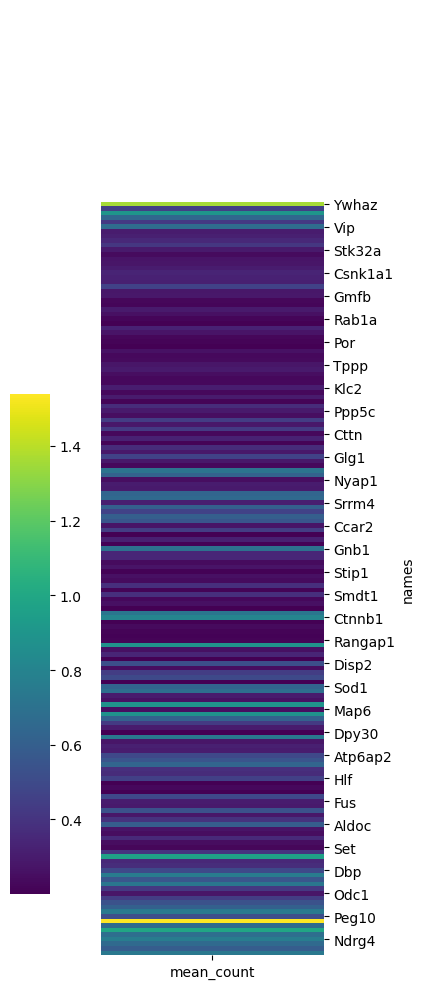

In [57]:
df_filter_sec = df_filter['SCH_Gaba'].filter(['names','mean_count'])
df_filter_sec.drop('names',axis=1, inplace=True)
sns.clustermap(df_filter_sec, cmap = 'viridis',# z_score=1,  center=0, vmin = -2, vmax = 2,
                col_cluster=False,row_cluster=False, cbar = 'upper left', cbar_pos=(-0.05,0.1,0.1,0.5),figsize=(4, 10),
                )

### All DEG

In [7]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [8]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [9]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [10]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

(1285, 2)

In [11]:
df.sort_values(by='count')

,Gene,count
1284,Sema3c,1
1228,Cxcl12,1
1167,Gas1,1
1078,Cyb561,1
135,Gfra1,1
...,...,...
1252,Bex3,47
1092,Pkm,47
1005,Ywhag,48
737,Ndrg4,49


Text(0.5, 0, 'Number of celltypes')

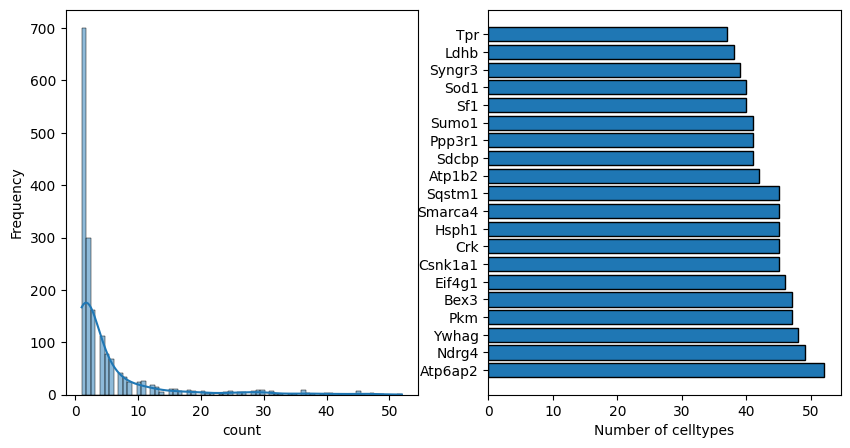

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [13]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

,Celltype,Cellclass
23,STR_D1_Gaba,Neuron
37,PVT_Glut,Neuron
10,AHN_Glut,Neuron
2,Pvalb_Gaba,Neuron
54,PVR_Gaba,Neuron


In [14]:
from module.misc import genes_list
import numpy as np

gene_index = genes_list('panel_5k_circa')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(len(gene_index)),
                              "Glial" : np.zeros(len(gene_index)),
                              'Vascular': np.zeros(len(gene_index)),
                              'Ependymal': np.zeros(len(gene_index))}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

Text(0.5, 0, 'Number of celltypes')

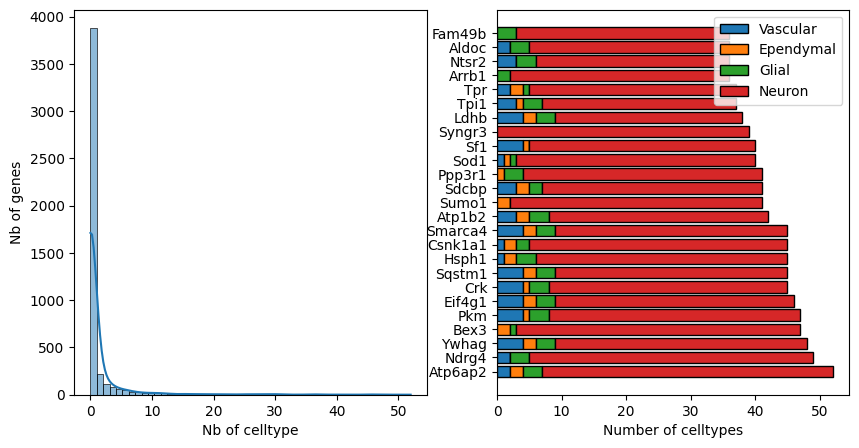

In [15]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

import seaborn as sns
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])
ax[0].set_ylabel('Nb of genes')
ax[0].set_xlabel('Nb of celltype')

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

# plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [16]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis.head()

,Neuron,Glial,Vascular,Ependymal,total
Atp6ap2,45.0,3.0,2.0,2.0,52.0
Ndrg4,44.0,3.0,2.0,0.0,49.0
Ywhag,39.0,3.0,4.0,2.0,48.0
Bex3,44.0,1.0,0.0,2.0,47.0
Pkm,39.0,3.0,4.0,1.0,47.0


Text(0.5, 0, 'Number of celltypes')

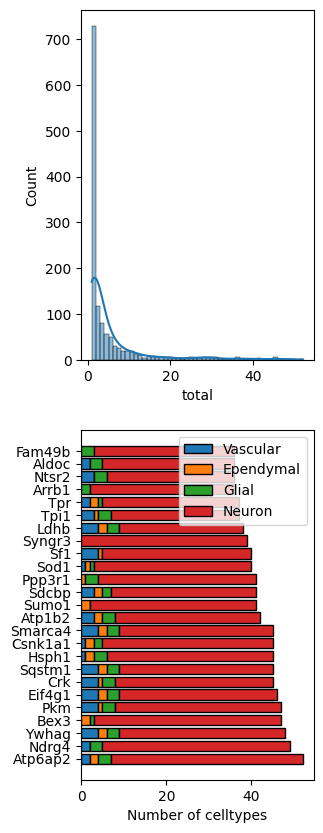

In [17]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]

import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

# plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
markers = ["Fam49b", "Aldoc", "Ntsr2", "Arrb1", "Tpr", "Tpi1", "Ldhb", "Syngr3", "Sf1", "Sod1", "Ppp3r1", "Sdcbp", "Sumo1", "Atp1b2",
            "Smarca4", "Csnk1a1", "Hsph1", "Sqstm1", "Crk", "Eif4g1", "Pkm", "Bex3", "Ywhag", "Ndrg4", "Atp6ap2"]



TypeError: 'float' object is not callable

In [137]:
fdf = pd.DataFrame(columns= markers ,
                   index = df_filter.keys(),
                   dtype= "float")

for idx, key in enumerate(df_filter.keys()):
    for idx_g, gene in enumerate(markers):
        if gene in df_filter[key]['names'].values:
            fdf.loc[key, gene] = float(df_filter[key].loc[gene,'logfoldchanges'])
        else:
            fdf.loc[key, gene] = float(0)

In [138]:
fdf

,Fam49b,Aldoc,Ntsr2,Arrb1,Tpr,Tpi1,Ldhb,Syngr3,Sf1,Sod1,...,Csnk1a1,Hsph1,Sqstm1,Crk,Eif4g1,Pkm,Bex3,Ywhag,Ndrg4,Atp6ap2
SI_Gaba,0.376599,-0.500880,-0.605981,-0.352735,0.438356,-0.339085,-0.381704,0.471310,-0.260243,-0.346620,...,0.466788,-0.416776,-0.463315,-0.281928,-0.284562,-0.564956,-0.472500,-0.355117,-0.394314,-0.405717
MEA_Glut,0.389476,-0.480148,-0.464083,0.000000,0.411323,-0.300993,-0.404556,0.286533,-0.277638,0.000000,...,0.491538,-0.460049,-0.482820,0.000000,-0.328133,-0.653848,-0.418146,-0.278179,-0.363207,-0.410353
Pvalb_Gaba,0.266022,-0.306923,-0.438923,-0.381072,0.451126,-0.317008,-0.280615,0.368114,-0.383627,-0.425251,...,0.472547,-0.388192,-0.455488,-0.409442,-0.420698,-0.447890,-0.508265,-0.366805,-0.412207,-0.377248
Sst_Gaba,0.349219,-0.451174,-0.536363,-0.306948,0.442748,-0.336146,-0.371262,0.405446,-0.329234,-0.351233,...,0.421630,-0.397304,-0.509730,-0.397605,-0.489362,-0.535790,-0.476225,-0.378496,-0.366664,-0.447493
PVH_SO_Glut,0.275913,0.000000,0.000000,0.000000,0.349940,0.000000,0.000000,0.415372,-0.323468,0.000000,...,0.561525,-0.478474,-0.271534,-0.372613,-0.310683,-0.391651,0.000000,-0.298541,-0.265276,-0.324938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MH_Glut,0.276243,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.713049,0.000000,-0.279967,...,0.517214,-0.399681,0.000000,-0.338703,0.000000,0.000000,0.000000,0.000000,-0.319325,-0.262800
L4_RSP_ACA_Glut,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.462803,0.000000,0.000000
AD_Glut,0.946187,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-0.631738,-0.789474,-0.520452,-0.461736,0.000000
LH_Glut,0.408375,0.000000,0.000000,0.000000,0.000000,0.000000,-0.275151,0.623208,-0.352842,-0.455033,...,0.528936,-0.348890,0.000000,0.000000,-0.319789,0.000000,-0.360176,0.000000,0.000000,-0.557293


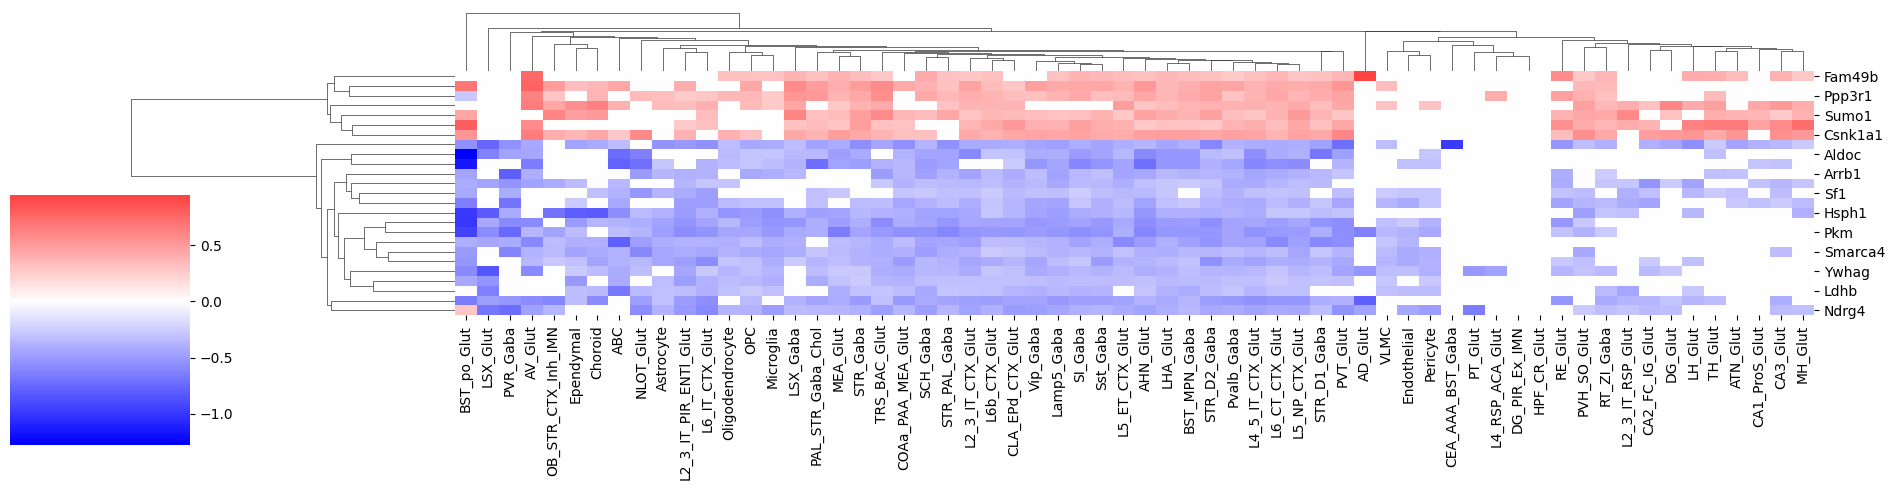

In [146]:
sns.clustermap(fdf.T, cmap = "bwr", center = 0, figsize=(18,5),cbar_pos=(-0.05,0.1,0.1,0.5))
plt.savefig(f'Gallery/{today}/top_DEG_heatmap.svg', transparent = True, dpi=300, format='svg')

## Quantif

In [18]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

,Celltype,Expressed,nb_DEG,Upregulated,Downregulated
Celltype,,,,,
SI_Gaba,SI_Gaba,747,118,40,78
MEA_Glut,MEA_Glut,773,94,32,62
Pvalb_Gaba,Pvalb_Gaba,684,102,22,80
Sst_Gaba,Sst_Gaba,702,100,22,78
PVH_SO_Glut,PVH_SO_Glut,737,75,38,37
...,...,...,...,...,...
MH_Glut,MH_Glut,644,94,85,9
L4_RSP_ACA_Glut,L4_RSP_ACA_Glut,721,16,8,8
AD_Glut,AD_Glut,641,29,15,14


In [19]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

KeyError: "['Tanycyte'] not found in axis"

In [20]:
# order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
#                'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
#                  'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
#                    'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
#                      'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
#                        'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
#                          'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
#                            'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
#                              'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
#                                'Astro TE', 'OPC', 'Oligodendrocyte']
# order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']

#circa-SD
order_list = ['Oligodendrocyte', 'Microglia', 'Choroid', 'ABC', 'VLMC', 'OB_STR_CTX_Inh_IMN', 'Ependymal', 'Tanycyte', 'OPC', 'Astrocyte', 'Endothelial', 'Pericyte', 'PVH_SO_Glut', 'PVR_Gaba', 'SCH_Gaba', 'MH_Glut', 'TRS_BAC_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut', 'LSX_Gaba', 'CEA_AAA_BST_Gaba', 'STR_PAL_Gaba', 'Sst_Gaba', 'Lamp5_Gaba', 'Vip_Gaba', 'Pvalb_Gaba', 'STR_Gaba', 'RT_ZI_Gaba', 'SI_Gaba', 'ATN_Glut', 'PT_Glut', 'RE_Glut', 'AD_Glut', 'AV_Glut', 'TH_Glut', 'LSX_Glut', 'BST_MPN_Gaba', 'COAa_PAA_MEA_Glut', 'PAL_STR_Gaba_Chol', 'PVT_Glut', 'BST_po_Glut', 'LH_Glut', 'MEA_Glut', 'AHN_Glut', 'LHA_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'DG_Glut', 'CA1_ProS_Glut', 'CA2_FC_IG_Glut', 'CA3_Glut', 'L2_3_IT_CTX_Glut', 'L4_5_IT_CTX_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_RSP_Glut', 'L5_ET_CTX_Glut', 'L5_NP_CTX_Glut', 'L6_IT_CTX_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'CLA_EPd_CTX_Glut', 'L2_3_IT_PIR_ENTl_Glut', 'NLOT_Glut']

### C123
# order_list=['L6_IT_CTX_Glut', 'L5_6_IT_TPE_ENT_Glut', 'L5_IT_CTX_Glut', 'CLA_EPd_CTX_Glut', 'IT_EP_CLA_Glut', 'L5_ET_CTX_Glut', 'Sub_Glut', 'L5_NP_CTX_Glut', 'NP_Glut', 'L6_CT_CTX_Glut', 'L6b_CTX_Glut', 'L6b_EPd_Glut', 'CA1_Glut', 'CA3_Glut', 'CA2_Glut', 'FC_Glut', 'DG_Glut', 'L2_3_IT_ENT_Glut', 'LA_BLA_BMA_PA_Glut', 'MEA_Glut', 'L4_RSP_ACA_Glut', 'L2_3_IT_CTX_Glut', 'L2_3_IT_RSP_Glut', 'L4_5_IT_CTX_Glut', 'STR_D1_Gaba', 'STR_D2_Gaba', 'CEA_BST_Gaba', 'STR_PAL_Gaba', 'RT_Gaba', 'SC_Gaba', 'LGv_Gaba', 'PRT_Gaba', 'ZI_Gaba', 'SNr_Gaba', 'STRv_Gaba', 'Vip_Gaba', 'Lamp5_Gaba', 'Sncg_Gaba', 'Pvalb_Gaba', 'Sst_Gaba', 'RHP_COA_Gaba', 'STR_Gaba', 'DMH_Glut', 'ARH_Glut', 'DMH_Gaba', 'ARH_Gaba', 'MEA_BST_Gaba', 'COAa_PAA_MEA_Glut', 'MEA_COA_BMA_Glut', 'VMH_Glut', 'LHA_Glut', 'PRC_PAG_Glut', 'PM_Glut', 'SPA_SPF_Glut', 'MH_Glut', 'MM_Glut', 'PVH_SO_PVa_Glut', 'STN_Glut', 'APN_Glut', 'SC_Glut', 'PF_Glut', 'SNc_VTA_RAmb_Dopa', 'LH_Glut', 'ND_INC_Glut', 'TH_Glut', 'OPC', 'Oligodendrocyte', 'Microglia', 'Endothelial', 'Pericyte', 'Ependymal', 'Hypendymal', 'Pineal_Glut', 'Tanycyte', 'Choroid', 'VLMC', 'HPF_CR_ Glut', 'Astro_NT', 'Astro_TE']


df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values('Celltype_order', inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

In [21]:
max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))

260

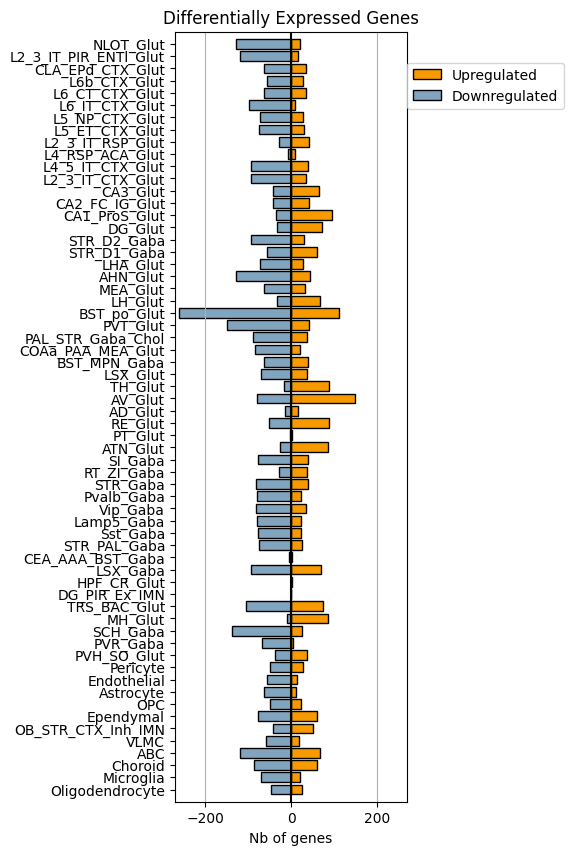

In [22]:
import matplotlib.pyplot as plt


plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
# plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Upregulated'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=-df_deg_quant['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black')
plt.legend(loc=(1,0.9))
plt.xlim((max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))*-1)-10, max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))+10)
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")
# plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

## Volcano plot

In [6]:
df_filter.keys()

dict_keys(['SI_Gaba', 'MEA_Glut', 'Pvalb_Gaba', 'Sst_Gaba', 'PVH_SO_Glut', 'LHA_Glut', 'BST_MPN_Gaba', 'Oligodendrocyte', 'Astrocyte', 'Ependymal', 'AHN_Glut', 'VLMC', 'SCH_Gaba', 'ABC', 'Lamp5_Gaba', 'STR_PAL_Gaba', 'L2_3_IT_PIR_ENTl_Glut', 'STR_Gaba', 'STR_D2_Gaba', 'L6b_CTX_Glut', 'L2_3_IT_CTX_Glut', 'L6_IT_CTX_Glut', 'L5_ET_CTX_Glut', 'STR_D1_Gaba', 'COAa_PAA_MEA_Glut', 'OPC', 'LSX_Gaba', 'NLOT_Glut', 'Endothelial', 'Choroid', 'Pericyte', 'L4_5_IT_CTX_Glut', 'Microglia', 'CLA_EPd_CTX_Glut', 'L6_CT_CTX_Glut', 'PAL_STR_Gaba_Chol', 'BST_po_Glut', 'PVT_Glut', 'PT_Glut', 'RE_Glut', 'OB_STR_CTX_Inh_IMN', 'L5_NP_CTX_Glut', 'Vip_Gaba', 'RT_ZI_Gaba', 'CA3_Glut', 'CEA_AAA_BST_Gaba', 'TRS_BAC_Glut', 'LSX_Glut', 'DG_PIR_Ex_IMN', 'HPF_CR_Glut', 'L2_3_IT_RSP_Glut', 'AV_Glut', 'TH_Glut', 'ATN_Glut', 'PVR_Gaba', 'CA2_FC_IG_Glut', 'DG_Glut', 'MH_Glut', 'L4_RSP_ACA_Glut', 'AD_Glut', 'LH_Glut', 'CA1_ProS_Glut'])

/tmp/ipykernel_162335/3079228097.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['logfoldchanges'][idx],
/tmp/ipykernel_162335/3079228097.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
/tmp/ipykernel_162335/3079228097.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,100000)


Text(0.5, 1.0, 'DEG: Choroid - Whole Brain')

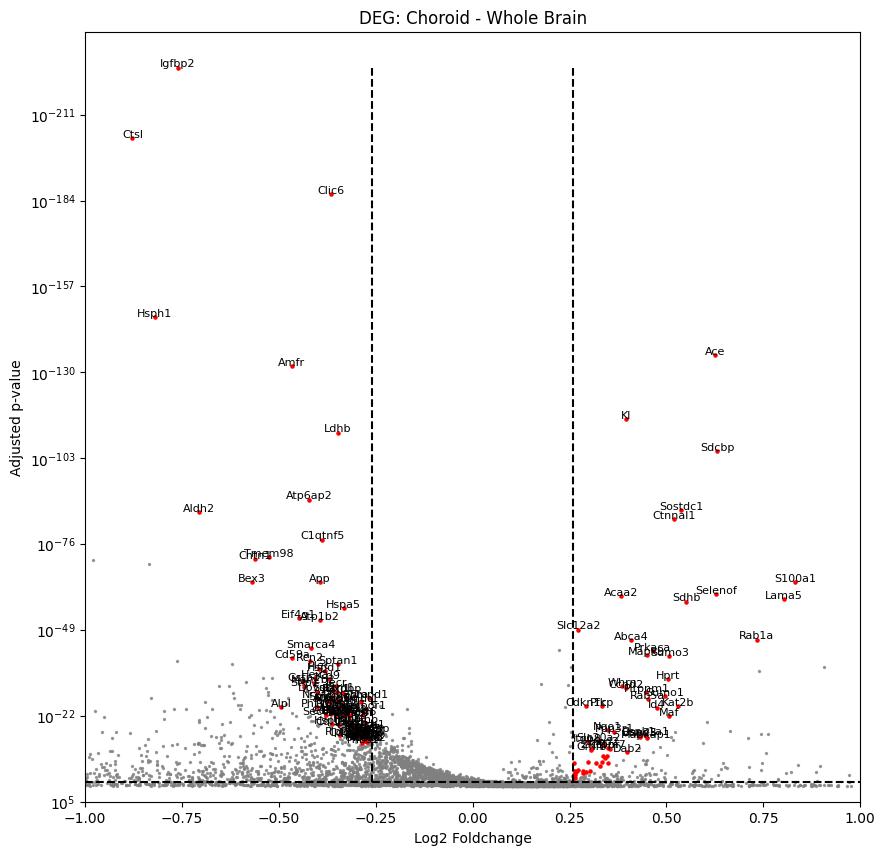

In [147]:
key = 'Choroid'
threshold_text = 1e-10

plt.figure(figsize=(10,10))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['logfoldchanges'][idx],
    df_filter[key][df_filter[key]['pvals_adj']< threshold_text]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-1,1)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - Whole Brain")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

In [35]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [148]:
import os
import pandas as pd
import matplotlib.pyplot as plt


directory_DEG = f'{dir_notebook}/analysis/{name_dir}/foldchanges/celltype_in_region'
region_of_interest = 'AMY'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [153]:
test_grp = 'SD1'

df_expressed = {}
for key in df_all.keys():
    if test_grp in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test_grp]
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1)& (df_all[key]['pct_nz_reference'] > 0.1) & df_all[key]['mean_count']>= 0.2]
    df_all[key].index = df_all[key]['names']

In [154]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.1)
                                 & (df_all[key]['pct_nz_reference'] > 0.1)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.2)
                                 ]

In [155]:
df_filter['Astrocyte']

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,mean_count
names,,,,,,,,,
Map2,Map2,8.737682,0.365495,2.379419e-18,3.157943e-16,0.903775,0.902462,SD1,1.804806
Kif5a,Kif5a,8.459600,0.391857,2.682949e-17,2.715028e-15,0.891015,0.885890,SD1,1.758957
Hpcal4,Hpcal4,7.721580,0.506567,1.148967e-14,7.428388e-13,0.687400,0.662405,SD1,0.974900
Gap43,Gap43,6.225990,0.431045,4.785251e-10,1.446451e-08,0.622010,0.596591,SD1,0.837523
Pink1,Pink1,6.114926,0.503283,9.660191e-10,2.692706e-08,0.569910,0.550189,SD1,0.687816
...,...,...,...,...,...,...,...,...,...
Gja1,Gja1,-10.015589,-0.698661,1.301841e-23,1.010012e-20,0.546518,0.677083,SD1,1.209474
Ntsr2,Ntsr2,-10.081638,-0.630552,6.660606e-24,6.201025e-21,0.615630,0.752367,SD1,1.169211
Ivd,Ivd,-10.175884,-0.871251,2.540826e-24,2.956887e-21,0.198299,0.345644,SD1,0.253043


In [156]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
# df_deg_quant = df_deg_quant[df_deg_quant["nb_DEG"] >= 5]
df_deg_quant.sort_values(by='nb_DEG', ascending = False)


,Celltype,Expressed,nb_DEG,Upregulated,Downregulated
Celltype,,,,,
Astrocyte,Astrocyte,1171,174,17,157
COAa_PAA_MEA_Glut,COAa_PAA_MEA_Glut,2103,110,21,89
L6_IT_CTX_Glut,L6_IT_CTX_Glut,1035,46,5,41
BST_MPN_Gaba,BST_MPN_Gaba,2074,46,8,38
Oligodendrocyte,Oligodendrocyte,1443,31,1,30
STR_PAL_Gaba,STR_PAL_Gaba,1970,21,3,18
MEA_Glut,MEA_Glut,2146,19,3,16
Endothelial,Endothelial,921,10,4,6
Pvalb_Gaba,Pvalb_Gaba,1813,3,0,3


In [157]:
import numpy as np

/tmp/ipykernel_162335/244829412.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filter[key]["-logQ"] = -np.log10(df_filter[key]["pvals_adj"].astype("float")+min_thr)
/tmp/ipykernel_162335/244829412.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(df_filter[key][df_filter[key]["-logQ"]>threshold_text]["logfoldchanges"][idx],
/tmp/ipykernel_162335/244829412.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 

Text(29.59722222222222, 0.5, '-Log10 Adjusted p-value')

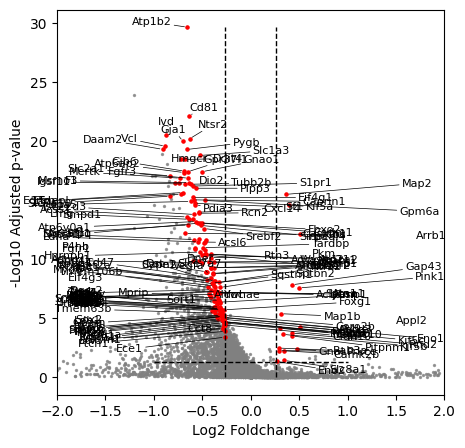

In [161]:
key = 'Astrocyte'

threshold_text = 0

min_thr = df_filter[key][df_filter[key]['pvals_adj'] != 0]['pvals_adj'].min()
df_filter[key]["-logQ"] = -np.log10(df_filter[key]["pvals_adj"].astype("float")+min_thr)
df_all[key]["-logQ"] = -np.log10(df_all[key]["pvals_adj"].astype("float")+min_thr)

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=0, ymax=max(df_all[key]["-logQ"]), color = "black", linestyles='dashed', linewidth = 1)
plt.hlines(y=-np.log10(0.05), xmin=-1, xmax=1, color = "black", linestyles='dashed', linewidth = 1)
plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]["-logQ"], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]["-logQ"], s=5, alpha=1, color = 'red')

texts = []
for idx, gene in enumerate(df_filter[key][df_filter[key]["-logQ"]>threshold_text]['names']):
    texts.append(plt.text(df_filter[key][df_filter[key]["-logQ"]>threshold_text]["logfoldchanges"][idx],
            df_filter[key][df_filter[key]["-logQ"]>threshold_text]["-logQ"][idx],
            str(gene), color = 'black', fontsize = 8, ha= 'center'))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
# plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,0)
# plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('-Log10 Adjusted p-value')
# plt.title(f"DEG: {key} - {region_of_interest}")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300, transparent = True)

## DEG celltype in diff regions

In [79]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
all_regions = os.listdir(directory_DEG)

In [81]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
all_regions.remove('Choroid_all_celltypes_DEG.xlsx')
all_regions.remove('Ependymal_all_celltypes_DEG.xlsx')
all_regions.remove('VLMC_all_celltypes_DEG.xlsx')
all_regions

['AHN_all_celltypes_DEG.xlsx',
 'PVT_all_celltypes_DEG.xlsx',
 'SCH_all_celltypes_DEG.xlsx',
 'STR_all_celltypes_DEG.xlsx',
 'LH_all_celltypes_DEG.xlsx',
 'BST_all_celltypes_DEG.xlsx',
 'RE_all_celltypes_DEG.xlsx',
 'AMY_all_celltypes_DEG.xlsx',
 'RT_all_celltypes_DEG.xlsx',
 'CTX_all_celltypes_DEG.xlsx',
 'AV_all_celltypes_DEG.xlsx',
 'LHA_all_celltypes_DEG.xlsx',
 'LSX_all_celltypes_DEG.xlsx',
 'HIPP_all_celltypes_DEG.xlsx',
 'TH_all_celltypes_DEG.xlsx',
 'ATN_all_celltypes_DEG.xlsx',
 'MH_all_celltypes_DEG.xlsx',
 'PVH_all_celltypes_DEG.xlsx',
 'TRS_all_celltypes_DEG.xlsx',
 'SI_all_celltypes_DEG.xlsx']

In [82]:
cell_type_inregion = "Pericyte"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

AHN
PVT
SCH
STR
LH
BST
RE
AMY
RT
CTX
AV
LHA
LSX
HIPP
TH
ATN
MH
PVH
TRS
SI


In [83]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [84]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                           & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.1)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.2)
                                           ]

In [86]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
# df_deg_quant.drop(['VLMC','Ependymal', "Choroid"], axis=0, inplace=True)
df_deg_quant = df_deg_quant[df_deg_quant['nb_DEG'] > 10]

Text(0.5, 1.0, 'DEG: Pericyte in different regions')

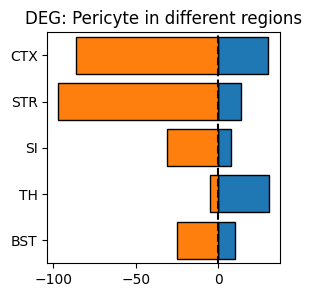

In [87]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title(f'DEG: {cell_type_inregion} in different regions')

In [90]:
celltype_inregion_DEG_filter['CTX'].sort_values(by="logfoldchanges")

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,mean_count
names,,,,,,,,,
Arc,Arc,-18.735374,-1.164152,2.548438e-78,1.186298e-74,0.131529,0.280520,SD1,0.230035
Ndrg4,Ndrg4,-14.581677,-0.773545,3.673796e-48,8.550761e-45,0.241484,0.370455,SD1,0.351908
Sptbn2,Sptbn2,-11.093811,-0.643577,1.344350e-28,6.257950e-26,0.171650,0.261374,SD1,0.228842
Atp2b2,Atp2b2,-11.506812,-0.537272,1.219013e-30,8.106434e-28,0.330242,0.438609,SD1,0.470354
Ddit4,Ddit4,-9.303613,-0.494107,1.357531e-20,2.527722e-18,0.201930,0.282452,SD1,0.246944
...,...,...,...,...,...,...,...,...,...
Grm3,Grm3,7.180203,0.426859,6.960799e-13,3.522013e-11,0.324943,0.273318,SD1,0.309546
Zic1,Zic1,11.265863,0.461875,1.934458e-29,1.000545e-26,0.579485,0.522747,SD1,0.693174
Ano1,Ano1,9.775734,0.483423,1.431160e-22,3.584254e-20,0.461204,0.395925,SD1,0.506141


/tmp/ipykernel_56663/4037975935.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['logfoldchanges'][idx],
/tmp/ipykernel_56663/4037975935.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['pvals_adj'][idx]*0.55,


Text(0, 0.5, 'Adjusted p-value')

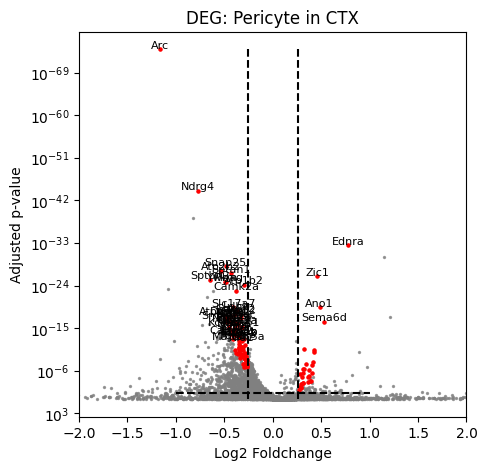

In [92]:
key = 'CTX'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['names']):
    plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['logfoldchanges'][idx],
             celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['pvals_adj'][idx]*0.55,
             str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
# plt.savefig(f'Gallery/{today}/volcano_plot_{cell_type_inregion}_in_{key}.svg')

In [ ]:
list_genes = set()
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes.update(temp)
len(list_genes)


## GO analysis

### Pre-process

In [36]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


In [37]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

HMS:0:01:30.145257 618,204 annotations, 26,443 genes, 19,022 GOs, 1 taxids READ: gene2go 
MF 19,140 annotated mouse genes
CC 22,723 annotated mouse genes
BP 21,889 annotated mouse genes


In [38]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

26326


In [39]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method




Load BP Ontology Enrichment Analysis ...
 71% 18,622 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 74% 19,591 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,738 of 26,326 population items found in association


In [40]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [41]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [42]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

#### DEG

In [43]:
key = 'Choroid'

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]['names'])

In [49]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [51]:
print(target_genes_up)

['Ace', 'Kl', 'Sdcbp', 'Sostdc1', 'Ctnnal1', 'Eif2a', 'S100a1', 'Selenof', 'Acaa2', 'Lama5', 'Sdhb', 'Slc12a2', 'Rab1a', 'Abca4', 'Prkaca', 'Mapk9', 'Mxd4', 'Sumo3', 'Tfrc', 'Nek7', 'Hprt', 'Whrn', 'Ccnd2', 'Pitpnm1', 'Sumo1', 'Rab5a', 'Pfkp', 'Kat2b', 'Cdkn1c', 'Id4', 'Maf', 'Chuk', 'Nqo1', 'Spag9', 'Glo1', 'Ppp3r1', 'Gmnc', 'Nr1d1', 'Csnk1a1', 'Usp25', 'Brwd3', 'Speg', 'Nup98', 'Mapkap1', 'Nipsnap2', 'Slc20a2', 'Itgb8', 'Alkbh5', 'Mbd2', 'Paxip1', 'Nfat5', 'Trpm7', 'Zic1', 'Tpr', 'Gmfb', 'Fbxl3', 'Dab2', 'Arhgef11', 'Huwe1', 'Neat1', 'Ube2m', 'Fundc1', 'Ggps1', 'Xiap', 'Dnajc7', 'Map3k7', 'Cdkn1b', 'Peg3', 'Sdc2', 'Ecpas', 'Brd4', 'Epc1', 'Skp1a', 'Appl2', 'Usp47', 'Spry2', 'Setd5', 'Clock', 'Ptp4a1', 'Lats1', 'Lrpprc', 'Kras', 'Tnks2', 'Ubap1', 'Cic', 'Sp3', 'Nrn1', 'Gigyf2', 'Spopl', 'Dlgap4', 'Dyrk1a', 'Ppp6r3', 'Npas2', 'Map2k2', 'Pafah1b1', 'Phb', 'Rbck1', 'E2f4', 'Mfn1', 'Eif4enif1', 'Dnah11', 'Klc1', 'Fzd6', 'Camk2g', 'Tbc1d1', 'Kdm7a', 'Hnrnpdl', 'Fbxl12', 'Taf9', 'Camk4', 'A

In [45]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        


Load BP Ontology Enrichment Analysis ...
 71% 18,622 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 74% 19,591 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,738 of 26,326 population items found in association

Runing BP Ontology Analysis: current study set of 140 IDs.
 99%    139 of    140 study items found in association
100%    140 of    140 study items found in population(26326)
Calculating 12,381 uncorrected p-values using fisher_scipy_stats
  12,381 terms are associated with 18,622 of 26,326 population items
   1,382 terms are associated with    139 of    140 study items
  METHOD fdr_bh:
      35 GO terms found significant (< 0.05=alpha) ( 35 enriched +   0 purified): statsmodels fdr_bh
      80 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 140 IDs.
 99%    

#### Cycling genes

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

#### Alternative list of genes

In [ ]:
list_gen = ddf_table[ddf_table['ratio_UNASSIGNED']>0.5]['Unnamed: 0'].values
print(*list_gen)

In [ ]:
### Alternative list of genes
target_genes_list = list_gen
target_genes_list = [id_mapper[gene] for gene in target_genes_list if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of mouse protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_list)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_list = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])



df_go_list.head(15)

### GO plot

In [46]:
df_go_down.head(5)
len(df_go_up)

40

NameError: name 'today' is not defined

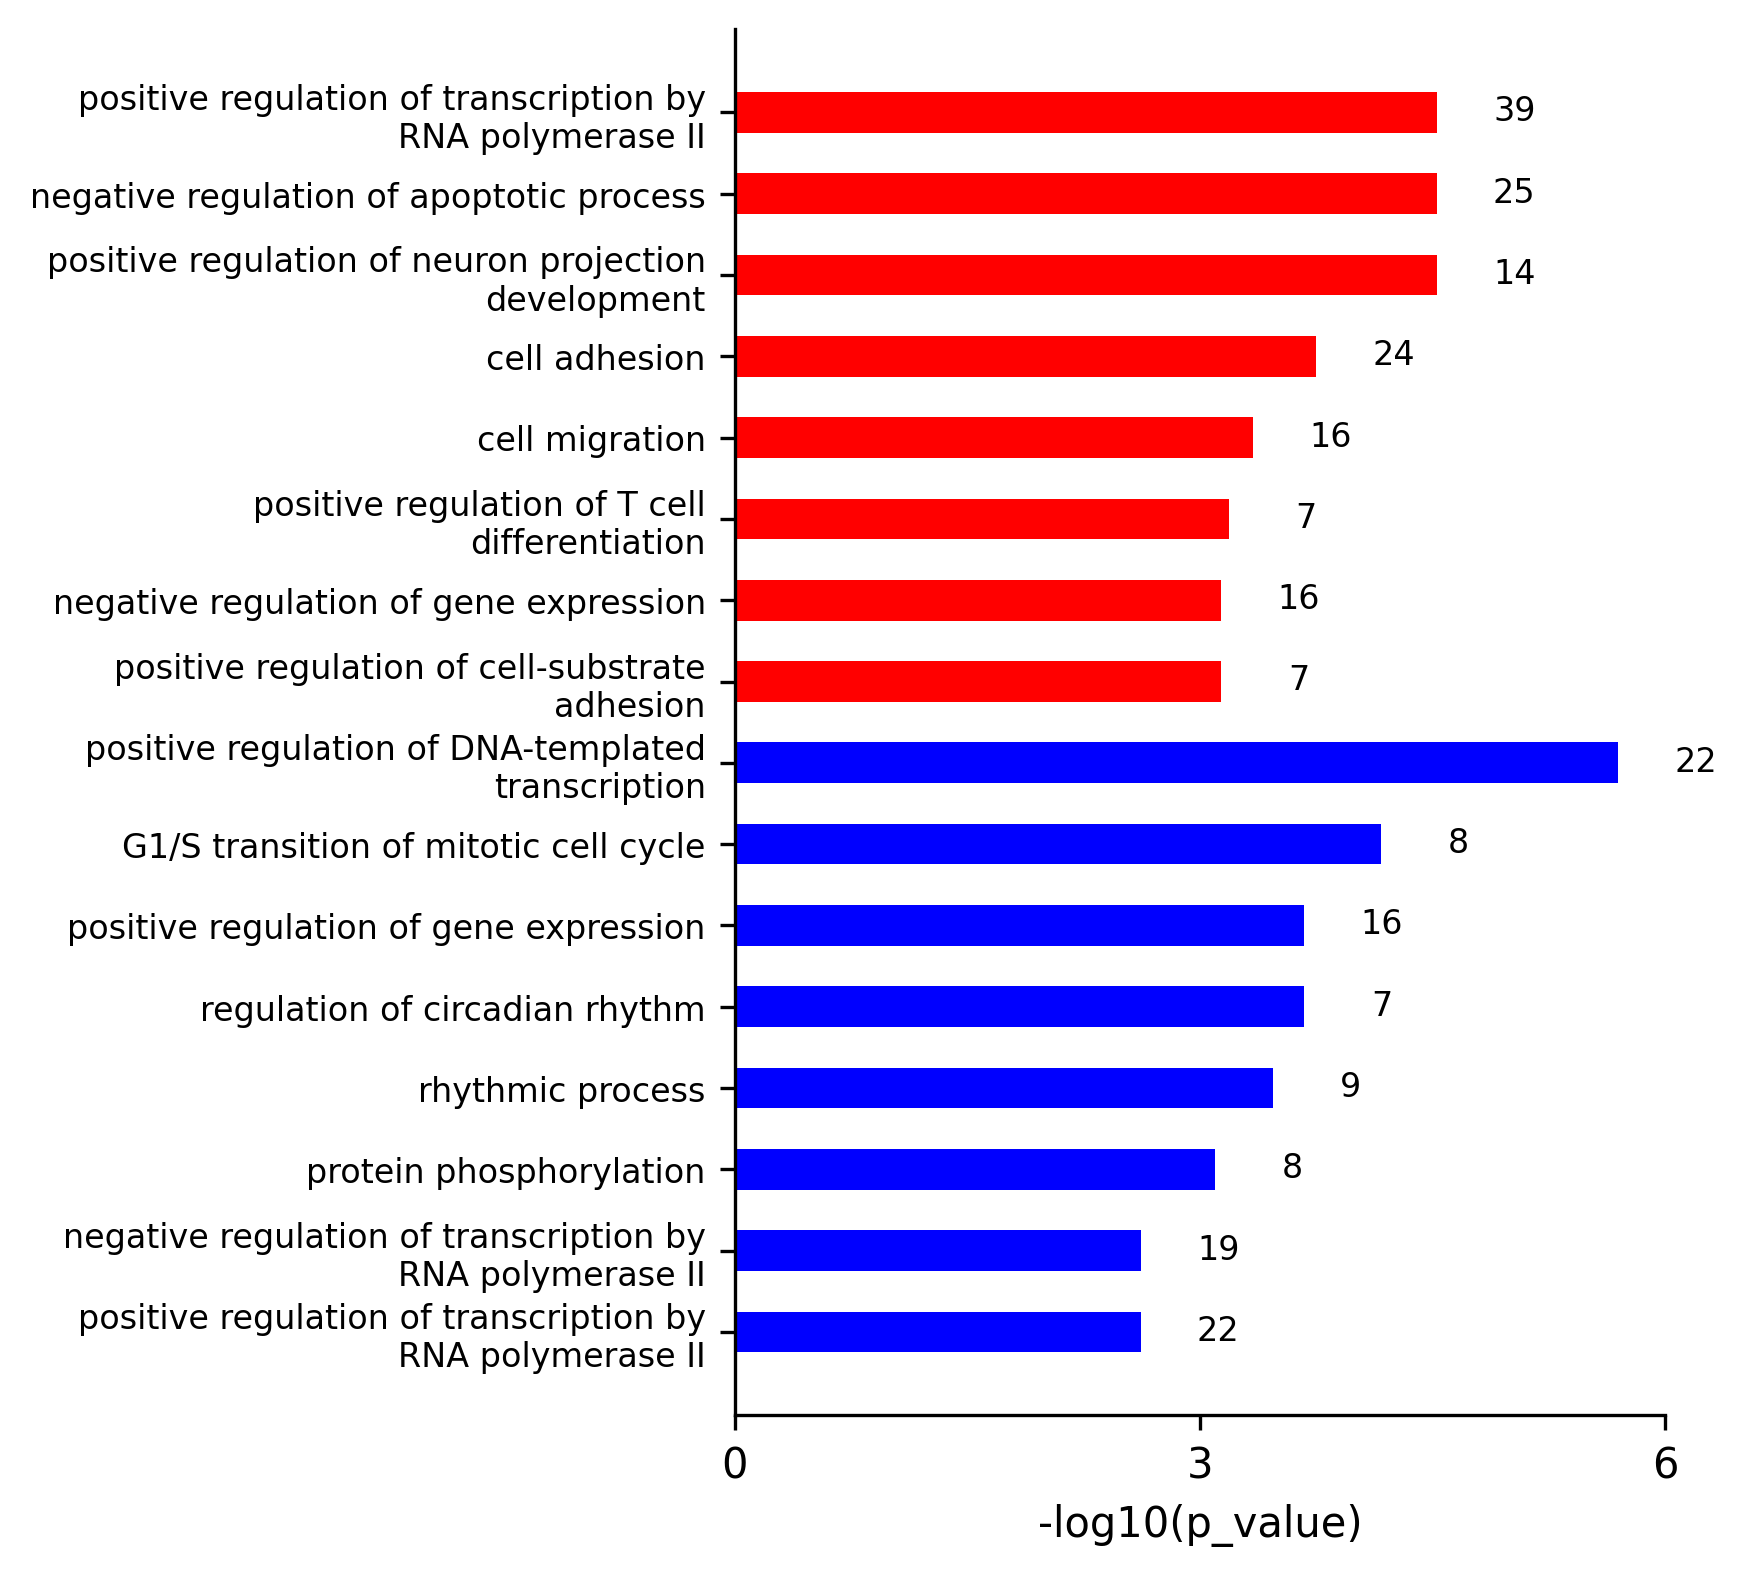

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
df_go_down

In [ ]:
filename_ = 'plaque_up'

df = pd.read_csv(f'data/Metascape/{filename_}.csv')
df.sample(1)
len(df)

7

C:\Users\hcall\AppData\Local\Temp\ipykernel_8528\1560865300.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')


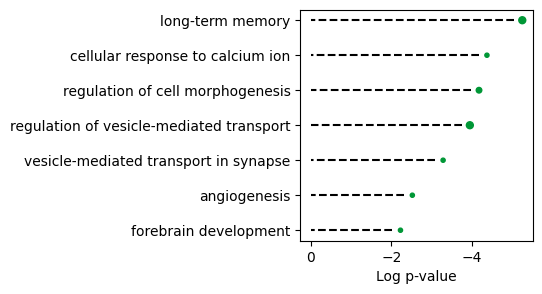

In [ ]:
plt.figure(figsize=(3,4))
plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')

for idx, go in enumerate(df['GO'].unique()):
    plt.hlines(y=df['GO'][idx], xmin=df['logP'][idx]+0.2, xmax=0, color = 'black', linestyle = 'dashed') 

plt.xlabel('Log p-value')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.savefig(f'Gallery/{today}/GO_{filename_}.svg', transparent= True, dpi=300)